In [1]:
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')

In [ ]:
df_scores.head(20)

,subject,mask_name,condition,score,chance_score
0,1,mofc,pre_age,0.750000,0.5
1,1,mofc,pre_category,0.500000,0.5
2,1,mofc,current_age,0.562500,0.5
3,1,mofc,current_category,0.578125,0.5
4,1,lofc,pre_age,0.562500,0.5
5,1,lofc,pre_category,0.625000,0.5
6,1,lofc,current_age,0.562500,0.5
7,1,lofc,current_category,0.671875,0.5
8,2,mofc,pre_age,0.625000,0.5
9,2,mofc,pre_category,0.468750,0.5


current_age-lOFC : 	 p= 0.4173 mu=50.32 std=6.90
current_age-mOFC : 	 p= 0.1688 mu=51.47 std=7.45
current_category-lOFC : 	 p= 0.0000 mu=57.32 std=7.55
current_category-mOFC : 	 p= 0.0000 mu=59.81 std=7.71
pre_age-lOFC : 	 p= 0.2879 mu=51.01 std=8.59
pre_age-mOFC : 	 p= 0.0132 mu=53.26 std=7.26
pre_category-lOFC : 	 p= 0.0004 mu=54.19 std=6.55
pre_category-mOFC : 	 p= 0.0160 mu=52.99 std=6.75


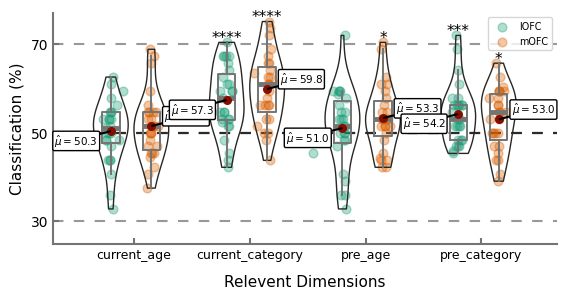

In [47]:
#Plot relevent_ofc
import pandas as pd
import math
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
df_scores = df_scores[~df_scores['mask_name'].isin(['HP', 'dlPFC', 'FFA/PPA'])]
import matplotlib.pyplot as plt
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(6.5,3))
jitter_dot = 0.025
jitter = 0.35  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#1B9E77", "#D95F02"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.2f} std={y_data_scale.std():.2f}')
        with open('/media/garlicseed/data/final/MVPA/2category_relevent/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p / 2 < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*'
        
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.35, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean

        if mask_name == "mOFC":
            ha = 'left'
            pos = i + j * jitter + 0.11
            text_position = mean_val + 2.2
        else:  # 对于 lofc 或者其他情况
            ha = 'right'
            pos = i + j * jitter - 0.11
            text_position = mean_val - 2.2

        # 计算文字和均值点之间的角度
        delta_x = pos - (i + j * jitter)
        delta_y = text_position - mean_val
        angle = math.atan2(delta_y, delta_x)

        # 为旋转角度加上一个微调值，这里以一定弧度为例，您可以根据需要调整
        # 这会轻微地改变直线的角度。对于 'mofc' 我们减小角度。
        angle_tweak = 0.1
        angle -= angle_tweak  # 减小角度以便让线条向下延伸


        # 计算直线的长度
        line_length = math.sqrt(delta_x**2 + delta_y**2)

        # 计算旋转后的直线终点坐标，保持长度不变
        new_x = (i + j * jitter) + math.cos(angle) * line_length
        new_y = mean_val + math.sin(angle) * line_length

        # 绘制旋转后的直线（从红点到新的终点）
        ax.plot([i + j * jitter, new_x], [mean_val, new_y], ls="dashdot", color="black", zorder=3)

        # 添加文本
        ax.text(pos, text_position, r"$\hat{\mu} = $" + str(round(mean_val, 1)), 
                fontsize=7.5, va="center", color="black", ha=ha,
                bbox=dict(
                    facecolor="white",
                    edgecolor="black",
                    boxstyle="round",
                    pad=0.15
                ), zorder=10)
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.3,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 11, 'ha': 'center', 'fontweight': 'normal'})
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.2, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Relevent Dimensions", size=11)
ax.xaxis.labelpad += 5
ax.legend(loc='upper right', fontsize='x-small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_ofc.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_ofc.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

current_age-HP : 	 p= 0.3830 mu=50.66 std=10.03
current_category-HP : 	 p= 0.0002 mu=55.82 std=6.95
pre_age-HP : 	 p= 0.4594 mu=50.20 std=8.32
pre_category-HP : 	 p= 0.0361 mu=52.35 std=6.32


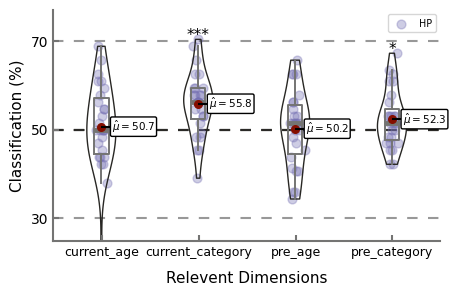

In [4]:
#Plot relevent_hp
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
df_scores = df_scores[df_scores['mask_name'] == 'HP']
import matplotlib.pyplot as plt
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(5,3))
jitter_dot = 0.025
jitter = 0.35  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#7570B3"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)
POSITIONS = [0, 1, 3, 4]
# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.2f} std={y_data_scale.std():.2f}')
        with open('/media/garlicseed/data/final/MVPA/2category_relevent/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p / 2 < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*'
        
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.35, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        ha = 'left'
        pos = i + j * jitter + 0.11
        ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.3,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 11, 'ha': 'center', 'fontweight': 'normal'})
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.005, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Relevent Dimensions", size=11)
ax.legend(loc='upper right', fontsize='x-small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
ax.xaxis.labelpad += 5#将xlabel下移
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_hp.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_hp.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

current_age-dlPFC : 	 p= 0.0041 mu=53.21 std=5.96
current_category-dlPFC : 	 p= 0.0000 mu=62.38 std=6.84
pre_age-dlPFC : 	 p= 0.2500 mu=50.90 std=6.43
pre_category-dlPFC : 	 p= 0.0003 mu=54.60 std=6.35


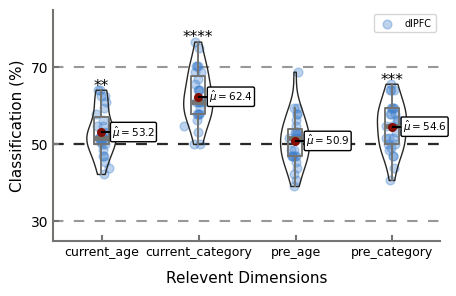

In [6]:
#Plot relevent_dlPFC
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] == 'dlPFC']
import matplotlib.pyplot as plt
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(5,3))
jitter_dot = 0.025
jitter = 0.35  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#4180cc"]#1940a6  #2d52b3
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)
POSITIONS = [0, 1, 3, 4]
# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.2f} std={y_data_scale.std():.2f}')
        with open('/media/garlicseed/data/final/MVPA/2category_relevent/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p / 2 < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*'
        
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.35, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        ha = 'left'
        pos = i + j * jitter + 0.11
        ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.3,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 11, 'ha': 'center', 'fontweight': 'normal'})
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.005, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 85)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Relevent Dimensions", size=11)
ax.legend(loc='upper right', fontsize='x-small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
ax.xaxis.labelpad += 5#将xlabel下移
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_dlPFC.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_dlPFC.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

current_age-FFA/PPA : 	 p= 0.0000 mu=59.41 std=6.55
current_category-FFA/PPA : 	 p= 0.0000 mu=81.06 std=7.49
pre_age-FFA/PPA : 	 p= 0.0797 mu=51.53 std=5.30
pre_category-FFA/PPA : 	 p= 0.0000 mu=62.14 std=6.05


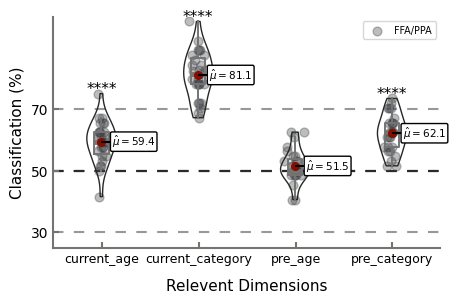

In [16]:
#Plot relevent_FFA/PPA
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] == 'FFA/PPA']
import matplotlib.pyplot as plt
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(5,3))
jitter_dot = 0.025
jitter = 0.35  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#404247"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)
POSITIONS = [0, 1, 3, 4]
# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.2f} std={y_data_scale.std():.2f}')
        #with open('/media/garlicseed/data/final/MVPA/2category_relevent/Sorces/stats.txt', 'a') as f:
            #f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            #f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p / 2 < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*'
        
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.35, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        ha = 'left'
        pos = i + j * jitter + 0.11
        ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.3,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 11, 'ha': 'center', 'fontweight': 'normal'})
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.005, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 100)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Relevent Dimensions", size=11)
ax.legend(loc='upper right', fontsize='x-small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
ax.xaxis.labelpad += 5#将xlabel下移
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_FFA-PPA.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_relevent/Figure/figure_FFA-PPA.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

age-lOFC : 	 p= 0.1039 mu=52.26 std=8.78
age-mOFC : 	 p= 0.2504 mu=51.39 std=9.95
category-lOFC : 	 p= 0.3430 mu=50.64 std=7.06
category-mOFC : 	 p= 0.1894 mu=51.33 std=7.16


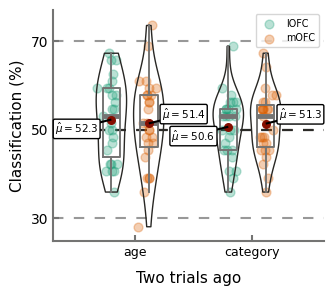

In [51]:
#Plot irrelevent_two_trials_age_ofc
import pandas as pd
import math
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/two_trials_ago_accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
df_scores = df_scores[~df_scores['mask_name'].isin(['HP', 'dlPFC', 'FFA/PPA'])]
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'age')
from mlxtend.evaluate import permutation_test
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(3.5,3))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#1B9E77", "#D95F02"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_data_scale = y_data * 100
        y_base = np.full_like( y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.2f} std={y_data_scale.std():.2f}')
        with open('/media/garlicseed/data/final/MVPA/2category_irrelevent/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*'       
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        if mask_name == "mOFC":
            ha = 'left'
            pos = i + j * jitter + 0.11
            text_position = mean_val + 2.1
        else:  # 对于 lofc 或者其他情况
            ha = 'right'
            pos = i + j * jitter - 0.11
            text_position = mean_val - 2.1

        # 计算文字和均值点之间的角度
        delta_x = pos - (i + j * jitter)
        delta_y = text_position - mean_val
        angle = math.atan2(delta_y, delta_x)

        # 为旋转角度加上一个微调值，这里以一定弧度为例，您可以根据需要调整
        # 这会轻微地改变直线的角度。对于 'mofc' 我们减小角度。
        angle_tweak = 0.1
        angle -= angle_tweak  # 减小角度以便让线条向下延伸


        # 计算直线的长度
        line_length = math.sqrt(delta_x**2 + delta_y**2)

        # 计算旋转后的直线终点坐标，保持长度不变
        new_x = (i + j * jitter) + math.cos(angle) * line_length
        new_y = mean_val + math.sin(angle) * line_length

        # 绘制旋转后的直线（从红点到新的终点）
        ax.plot([i + j * jitter, new_x], [mean_val, new_y], ls="dashdot", color="black", zorder=3)

        # 添加文本
        ax.text(pos, text_position, r"$\hat{\mu} = $" + str(round(mean_val, 1)), 
                fontsize=7.5, va="center", color="black", ha=ha,
                bbox=dict(
                    facecolor="white",
                    edgecolor="black",
                    boxstyle="round",
                    pad=0.15
                ), zorder=10)
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.26,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)
        
        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})        

# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.2, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Two trials ago", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
ax.legend(loc='upper right', fontsize='x-small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_ofc_TTA.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_ofc_TTA.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

age-HP : 	 p= 0.9775 mu=49.8843
category-HP : 	 p= 0.5663 mu=50.9838


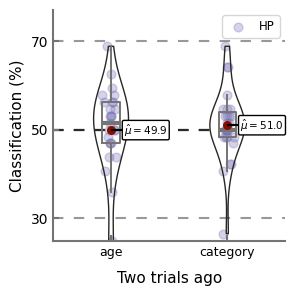

In [52]:
#Plot irrelevent_two_trials_ago_hp
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/two_trials_ago_accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
df_scores = df_scores[df_scores['mask_name'] == 'HP']
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'age')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())
POSITIONS = [0, 1]
fig, ax = plt.subplots(figsize=(3,3))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#7570B3"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
        #with open('/media/garlicseed/data/final/MVPA/2category_irrelevent/Sorces/stats.txt', 'a') as f:
            #f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            #f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*' 
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        ha = 'left'
        pos = i + j * jitter + 0.11
        ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.30,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Two trials ago", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
ax.legend(loc='upper right', fontsize='small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_hp_TTA.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_hp_TTA.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

age-dlPFC : 	 p= 0.3061 mu=51.6204
category-dlPFC : 	 p= 0.8404 mu=50.3472


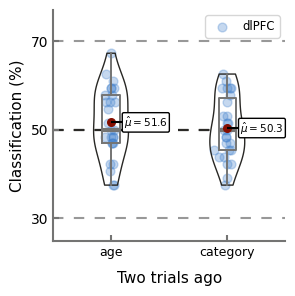

In [5]:
#Plot irrelevent_two_trials_ago_dlPFC
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/two_trials_ago_accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] == 'dlPFC']
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'age')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())
POSITIONS = [0, 1]
fig, ax = plt.subplots(figsize=(3,3))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#4180cc"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
        with open('/media/garlicseed/data/final/MVPA/2category_irrelevent/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p / 2 < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*' 
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        ha = 'left'
        pos = i + j * jitter + 0.11
        ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.30,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Two trials ago", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
ax.legend(loc='upper right', fontsize='small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_dlPFC_TTA.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_dlPFC_TTA.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

age-FFA/PPA : 	 p= 0.0835 mu=52.1412
category-FFA/PPA : 	 p= 0.0001 mu=57.9861


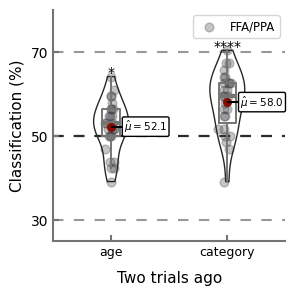

In [11]:
#Plot irrelevent_two_trials_ago_FFA/PPA
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/two_trials_ago_accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] == 'FFA/PPA']
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'age')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())
POSITIONS = [0, 1]
fig, ax = plt.subplots(figsize=(3,3))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [30 , 50, 70]
COLOR_SCALE = ["#404247"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values
        y_data_scale = y_data * 100
        y_base = np.full_like(y_data_scale, 50)
        t1, p1 = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data_scale, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
        #with open('/media/garlicseed/data/final/MVPA/2category_irrelevent/Sorces/stats.txt', 'a') as f:
            #f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            #f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
        ts = ''
        if p / 2 < 0.05:
            if p / 2 < (0.0001 ):
                ts = '*' * 4
            elif p / 2 < (0.001 ):
                ts = '*' * 3
            elif p / 2 < (0.01 ):
                ts = '*' * 2
            elif p / 2 < (0.05 ):
                ts = '*' 
        x_data = np.array([i + j * jitter] * len(y_data_scale))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3, label=mask_name if i == 0 else "")
        
        mean_val = y_data_scale.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        ha = 'left'
        pos = i + j * jitter + 0.11
        ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data_scale, positions=[i + j * jitter], widths=0.30,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data_scale, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data_scale)+0.02, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 80)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Two trials ago", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
ax.legend(loc='upper right', fontsize='small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_FFA-PPA_TTA.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2category_irrelevent/Figure/figure_FFA-PPA_TTA.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

In [39]:
#Plot irrelevent-dimensions_ofc
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/irre_dimensions_accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] != 'hp']
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'pre_category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'pre_age')
df_scores['condition'] = df_scores['condition'].replace('current_irre_category', 'current_category')
df_scores['condition'] = df_scores['condition'].replace('current_irre_age', 'current_age')
import matplotlib.pyplot as plt
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(6,4))
jitter_dot = 0.025
jitter = 0.35  # Increase the jitter or separation between mofc and lofc
HLINES = [0.3 , 0.5, 0.7]
COLOR_SCALE = ["#1B9E77", "#D95F02"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_base = np.full_like(y_data, 0.5)
        #t, p = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data.mean():.4f}')

        ts = ''
        if p < 0.05:
            if p < (0.0001 ):
                ts = '*' * 4
            elif p < (0.001 ):
                ts = '*' * 3
            elif p < (0.01 ):
                ts = '*' * 2
            elif p < (0.05 ):
                ts = '*'
        
        x_data = np.array([i + j * jitter] * len(y_data))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data, s = 40, color=COLOR_SCALE[j], alpha=0.35, label=mask_name if i == 0 else "")
        
        mean_val = y_data.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        if mask_name == "mofc":
            ha = 'left'
            pos = i + j * jitter + 0.1
            ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        else:
            ha = 'right'
            pos = i + j * jitter - 0.1
            ax.plot([pos, i + j * jitter], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 2)), fontsize=6, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data, positions=[i + j * jitter], widths=0.3,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data)+0.01, ts, {'fontsize': 11, 'ha': 'center', 'fontweight': 'normal'})
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.2, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(1.5)
#plt.ylim(0.25, 0.8)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification", size=11)
ax.set_xlabel("Irrelevent Dimensions", size=11)
ax.legend(loc='upper right', fontsize='small')
plt.show()

['pre_irre_age', 'pre_irre_category']

In [43]:
#Plot irrelevent-dimensions_hp
import pandas as pd
df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/irre_dimensions_accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] == 'hp']
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'pre_category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'pre_age')
df_scores['condition'] = df_scores['condition'].replace('current_irre_category', 'current_category')
df_scores['condition'] = df_scores['condition'].replace('current_irre_age', 'current_age')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())
POSITIONS = [0, 1]
fig, ax = plt.subplots(figsize=(3,4))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [0.3 , 0.5, 0.7]
COLOR_SCALE = ["#1B9E77", "#D95F02"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values
        y_base = np.full_like(y_data, 0.5)
        #t, p = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data.mean():.4f}')

        ts = ''
        if p < 0.05:
            if p < (0.0001 ):
                ts = '*' * 4
            elif p < (0.001 ):
                ts = '*' * 3
            elif p < (0.01 ):
                ts = '*' * 2
            elif p < (0.05 ):
                ts = '*' 
        x_data = np.array([i + j * jitter] * len(y_data))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data, s = 40, color=COLOR_SCALE[j], alpha=0.3, label=mask_name if i == 0 else "")
        
        mean_val = y_data.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        if mask_name == "mofc":
            ha = 'left'
            pos = i + j * jitter + 0.1
            ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        else:
            ha = 'right'
            pos = i + j * jitter - 0.1
            ax.plot([pos, i + j * jitter], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 2)), fontsize=6, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data, positions=[i + j * jitter], widths=0.30,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter , np.max(y_data)+0.01, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.1, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(0.25, 0.8)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification", size=11)
ax.set_xlabel("Irrelevent Dimensions", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
ax.legend(loc='upper right', fontsize='small')
plt.show()

,subject,mask_name,condition,score,chance_score
0,1,mofc,pre_irre_age,0.343750,0.5
1,1,mofc,pre_irre_category,0.406250,0.5
2,1,lofc,pre_irre_age,0.468750,0.5
3,1,lofc,pre_irre_category,0.437500,0.5
4,1,hp,pre_irre_age,0.546875,0.5
...,...,...,...,...,...
145,30,mofc,pre_irre_category,0.609375,0.5
146,30,lofc,pre_irre_age,0.375000,0.5
147,30,lofc,pre_irre_category,0.484375,0.5
148,30,hp,pre_irre_age,0.640625,0.5


lOFC : 	 p= 0.0001 mu=10.1350
mOFC : 	 p= 0.0030 mu=8.9120


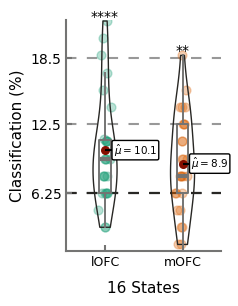

In [14]:
#Plot 16states
import pandas as pd
df_scores = pd.read_csv('/home/garlicseed/Mount/final/MVPA/16way_classifier/Scores/accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC'}, inplace=True)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
#mask_names = sorted(df_scores["mask_name"].unique())
mask_names = ['lOFC','mOFC']
POSITIONS = [0, 1]

fig, ax = plt.subplots(figsize=(2,3))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [6.25, 12.5, 18.5]
COLOR_SCALE = ["#1B9E77", "#D95F02","#7570B3"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(6.25, color="#282724", ls=(0, (5, 5)), alpha=0.8, zorder=0)
for j, mask_name in enumerate(mask_names):
    y_data = df_scores[(df_scores["mask_name"] == mask_name)]["score"].values
    y_data_scale = y_data * 100
    y_base = np.full_like(y_data_scale, 6.25)
    t1, p1 = ttest_1samp(y_data, 0.0625)
    p = permutation_test(y_data_scale, y_base,
                       method='approximate',
                       num_rounds=10000,
                       seed=0)
    print(f'{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
    #with open('/media/garlicseed/data/final/MVPA/16way_classifier/Scores/stats.txt', 'a') as f:
            #f.write(f'perm_test\t{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            #f.write(f't_test\t{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
    ts = ''
    if p / 2 < 0.05:
        if p / 2 < (0.0001 ):
            ts = '*' * 4
        elif p / 2 < (0.001 ):
            ts = '*' * 3
        elif p / 2 < (0.01 ):
            ts = '*' * 2
        elif p / 2 < (0.05 ):
            ts = '*' 
    x_data = np.array([j] * len(y_data_scale))
    x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
    ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3,label=mask_name)

    mean_val = y_data_scale.mean() # Calculate the mean
    ax.scatter(j , mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
    ha = 'left'
    pos = j  + 0.11
    ax.plot([j, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)

    ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round",
        pad=0.15
    ),zorder=10)        


    violins = ax.violinplot(y_data_scale, positions=[j], widths=0.31,
                            bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
    for pc in violins["bodies"]:
        pc.set_facecolor('none')
        pc.set_edgecolor(BLACK)
        pc.set_linewidth(1)
        pc.set_alpha(1)

    boxprops = dict(linewidth=1.4, color=GREY_DARK)
    medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
    ax.boxplot(y_data_scale, positions=[j], widths=0.15, showcaps=False, 
                boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)
    ax.text( j  , np.max(y_data_scale)+0.02, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  

# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(mask_names, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(1, 22)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("16 States", size=11)
ax.xaxis.labelpad += 5#将xlabel下移

ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
#ax.legend(loc='upper right', fontsize='small')
plt.savefig("/media/garlicseed/data/final/MVPA/16way_classifier/Figure/figure.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/16way_classifier/Figure/figure.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

lOFC : 	 p= 0.9894 mu=50.0109
mOFC : 	 p= 0.0005 mu=53.6842


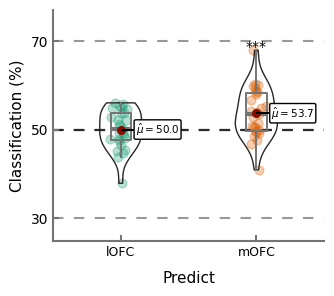

In [3]:
#Plot 2relevent_predict
import pandas as pd
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
df_scores = pd.read_csv('/home/garlicseed/Mount/final/MVPA/2relevent_predict/Sorces/accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
#mask_names = sorted(df_scores["mask_name"].unique())
mask_names = ['lOFC','mOFC']
POSITIONS = [0, 1]

fig, ax = plt.subplots(figsize=(3.5,3))
jitter_dot = 0.025
jitter = 0.25  # Increase the jitter or separation between mofc and lofc
HLINES = [30, 50, 70]
COLOR_SCALE = ["#1B9E77", "#D95F02"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)

for j, mask_name in enumerate(mask_names):
    y_data = df_scores[(df_scores["mask_name"] == mask_name)]["score"].values
    y_data_scale = y_data * 100
    y_base = np.full_like(y_data_scale, 50)
    t1, p1 = ttest_1samp(y_data, 0.5)
    p = permutation_test(y_data_scale, y_base,
                       method='approximate',
                       num_rounds=10000,
                       seed=0)
    print(f'{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
    with open('/media/garlicseed/data/final/MVPA/2relevent_predict/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
    ts = ''
    if p / 2 < 0.05:
        if p / 2 < (0.0001 ):
            ts = '*' * 4
        elif p / 2 < (0.001 ):
            ts = '*' * 3
        elif p / 2 < (0.01 ):
            ts = '*' * 2
        elif p / 2 < (0.05 ):
            ts = '*' 
    x_data = np.array([j] * len(y_data_scale))
    x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
    ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3,label=mask_name)

    mean_val = y_data_scale.mean() # Calculate the mean
    ax.scatter(j , mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean

    ha = 'left'
    pos = j  + 0.11
    ax.plot([j, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
    ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round",
        pad=0.15
    ),zorder=10)        


    violins = ax.violinplot(y_data_scale, positions=[j], widths=0.31,
                            bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
    for pc in violins["bodies"]:
        pc.set_facecolor('none')
        pc.set_edgecolor(BLACK)
        pc.set_linewidth(1)
        pc.set_alpha(1)

    boxprops = dict(linewidth=1.4, color=GREY_DARK)
    medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
    ax.boxplot(y_data_scale, positions=[j], widths=0.15, showcaps=False, 
                boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)
    ax.text( j  , np.max(y_data_scale)+0.01, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  

# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(mask_names, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Predict", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
#ax.legend(loc='upper right', fontsize='small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2relevent_predict/Figure/figure_ofc.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2relevent_predict/Figure/figure_ofc.png", dpi=300, format="png", bbox_inches='tight')
plt.show()


HP : 	 p= 0.7880 mu=50.2386
dlPFC : 	 p= 0.2388 mu=51.1661
FFA/PPA : 	 p= 0.1025 mu=51.8190


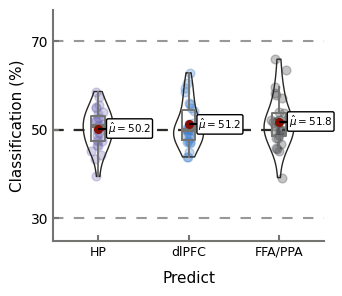

In [63]:
#Plot 2relevent_predict
import pandas as pd
from mlxtend.evaluate import permutation_test
df_scores = pd.read_csv('/home/garlicseed/Mount/final/MVPA/2relevent_predict/Sorces/accuray.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
#mask_names = sorted(df_scores["mask_name"].unique())
mask_names = ['HP','dlPFC','FFA/PPA']
POSITIONS = [0, 1, 2]

fig, ax = plt.subplots(figsize=(3.5,3))
jitter_dot = 0.025
jitter = 0.25  # Increase the jitter or separation between mofc and lofc
HLINES = [30, 50, 70]
COLOR_SCALE = ["#7570B3", "#4180cc", "#404247"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)

for j, mask_name in enumerate(mask_names):
    y_data = df_scores[(df_scores["mask_name"] == mask_name)]["score"].values
    y_data_scale = y_data * 100
    y_base = np.full_like(y_data_scale, 50)
    t1, p1 = ttest_1samp(y_data, 0.5)
    p = permutation_test(y_data_scale, y_base,
                       method='approximate',
                       num_rounds=10000,
                       seed=0)
    print(f'{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
    with open('/media/garlicseed/data/final/MVPA/2relevent_predict/Sorces/stats.txt', 'a') as f:
            f.write(f'perm_test\t{condition}-{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{condition}-{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
    ts = ''
    if p / 2 < 0.05:
        if p / 2 < (0.0001 ):
            ts = '*' * 4
        elif p / 2 < (0.001 ):
            ts = '*' * 3
        elif p / 2 < (0.01 ):
            ts = '*' * 2
        elif p / 2 < (0.05 ):
            ts = '*' 
    x_data = np.array([j] * len(y_data_scale))
    x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
    ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3,label=mask_name)

    mean_val = y_data_scale.mean() # Calculate the mean
    ax.scatter(j , mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean

    ha = 'left'
    pos = j  + 0.11
    ax.plot([j, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
    ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round",
        pad=0.15
    ),zorder=10)        


    violins = ax.violinplot(y_data_scale, positions=[j], widths=0.33,
                            bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
    for pc in violins["bodies"]:
        pc.set_facecolor('none')
        pc.set_edgecolor(BLACK)
        pc.set_linewidth(1)
        pc.set_alpha(1)

    boxprops = dict(linewidth=1.4, color=GREY_DARK)
    medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
    ax.boxplot(y_data_scale, positions=[j], widths=0.15, showcaps=False, 
                boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)
    ax.text( j  , np.max(y_data_scale)+0.01, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  

# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(mask_names, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Predict", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
#ax.legend(loc='upper right', fontsize='small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2relevent_predict/Figure/figure_control.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2relevent_predict/Figure/figure_control.png", dpi=300, format="png", bbox_inches='tight')
plt.show()


lOFC : 	 p= 0.9386 mu=50.0716
mOFC : 	 p= 0.1313 mu=51.3403
HP : 	 p= 0.3883 mu=50.7227
dlPFC : 	 p= 0.3391 mu=50.6587
FFA/PPA : 	 p= 0.1635 mu=51.5846


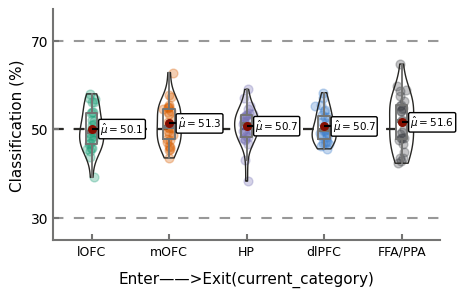

In [3]:
#Plot 2relevent_predict_reversal
import pandas as pd
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
df_scores = pd.read_csv('/home/garlicseed/Mount/final/MVPA/2relevent_predict/Sorces/accuray_reversal.tsv',sep='\t')
df_scores['mask_name'].replace({'mofc': 'mOFC', 'lofc': 'lOFC','hp':'HP'}, inplace=True)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
#mask_names = sorted(df_scores["mask_name"].unique())
mask_names = ['lOFC','mOFC','HP','dlPFC','FFA/PPA']
POSITIONS = [0, 1, 2, 3, 4]

fig, ax = plt.subplots(figsize=(5,3))
jitter_dot = 0.025
jitter = 0.25  # Increase the jitter or separation between mofc and lofc
HLINES = [30, 50, 70]
COLOR_SCALE = ["#1B9E77", "#D95F02","#7570B3", "#4180cc", "#404247"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
    ax.axhline(50, color=BLACK, ls=(0, (5, 5)), alpha=0.8, zorder=0)

for j, mask_name in enumerate(mask_names):
    y_data = df_scores[(df_scores["mask_name"] == mask_name)]["score"].values
    y_data_scale = y_data * 100
    y_base = np.full_like(y_data_scale, 50)
    t1, p1 = ttest_1samp(y_data, 0.5)
    p = permutation_test(y_data_scale, y_base,
                       method='approximate',
                       num_rounds=10000,
                       seed=0)
    print(f'{mask_name} : \t p= {p:.4f} mu={y_data_scale.mean():.4f}')
    with open('/media/garlicseed/data/final/MVPA/2relevent_predict/Sorces/stats_irr.txt', 'a') as f:
            f.write(f'perm_test\t{mask_name} : \t p= {p / 2:.4f} mu={y_data_scale.mean():.4f} std={y_data_scale.std():.2f}\n')
            f.write(f't_test\t{mask_name} : \t p= {p1 / 2:.4f} t= {t1:.4f} \n')
    ts = ''
    if p / 2  < 0.05:
        if p / 2 < (0.0001 ):
            ts = '*' * 4
        elif p / 2 < (0.001 ):
            ts = '*' * 3
        elif p / 2 < (0.01 ):
            ts = '*' * 2
        elif p / 2 < (0.05 ):
            ts = '*' 
    x_data = np.array([j] * len(y_data_scale))
    x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
    ax.scatter(x_data, y_data_scale, s = 40, color=COLOR_SCALE[j], alpha=0.3,label=mask_name)

    mean_val = y_data_scale.mean() # Calculate the mean
    ax.scatter(j , mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean

    ha = 'left'
    pos = j  + 0.11
    ax.plot([j, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
    ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 1)), fontsize=7.5, va="center",color="black", ha=ha,bbox = dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round",
        pad=0.15
    ),zorder=10)        


    violins = ax.violinplot(y_data_scale, positions=[j], widths=0.31,
                            bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
    for pc in violins["bodies"]:
        pc.set_facecolor('none')
        pc.set_edgecolor(BLACK)
        pc.set_linewidth(1)
        pc.set_alpha(1)

    boxprops = dict(linewidth=1.4, color=GREY_DARK)
    medianprops = dict(linewidth=3, color=GREY_DARK, solid_capstyle="butt")
    ax.boxplot(y_data_scale, positions=[j], widths=0.15, showcaps=False, 
                boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)
    ax.text( j  , np.max(y_data_scale)+0.01, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})  

# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(POSITIONS)
ax.set_xticklabels(mask_names, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(25, 77)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification (%)", size=11)
ax.set_xlabel("Enter——>Exit(current_category)", size=11)
ax.xaxis.labelpad += 5#将xlabel下移
#ax.legend(loc='upper right', fontsize='small')
ax.tick_params(axis='both', which='major', length=4, width=1.5,color = GREY_DARK,direction='in')
plt.savefig("/media/garlicseed/data/final/MVPA/2relevent_predict/Figure/figure_reversal.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/MVPA/2relevent_predict/Figure/figure_reversal.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

array([0.57279102, 0.57652703, 0.57162058, 0.49733964, 0.5797619 ,
       0.52959017, 0.54026442, 0.51288469, 0.49752149, 0.60471705,
       0.55322581, 0.58934406, 0.50915079, 0.57927956, 0.48482759,
       0.50230847, 0.47253031, 0.52095611, 0.54054505, 0.57157258,
       0.51415721, 0.48390805, 0.50232335, 0.50597782, 0.56167385,
       0.52965158, 0.45909455])